In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [5]:
import pandas as pd

df = pd.read_csv('diabetes.csv.csv')
# Show data
print(df.head())   # first 5 rows

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [6]:
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 n

In [7]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


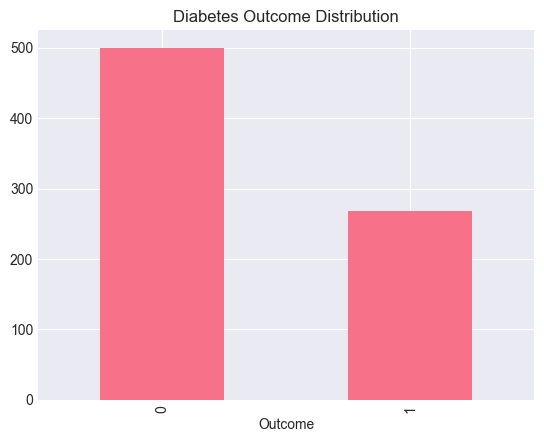

In [8]:
df['Outcome'].value_counts().plot(kind='bar')
plt.title("Diabetes Outcome Distribution")
plt.show()

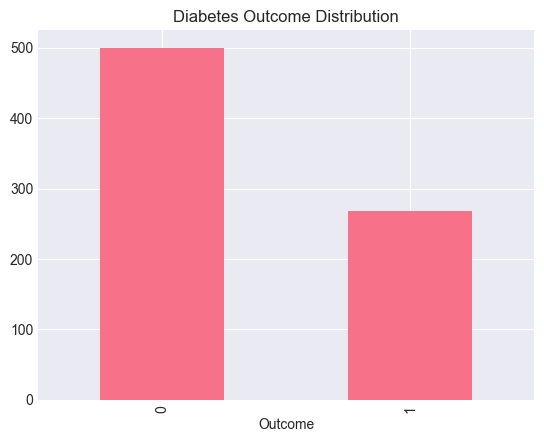

In [9]:
#outcome distribution
df['Outcome'].value_counts().plot(kind='bar')
plt.title("Diabetes Outcome Distribution")
plt.show()

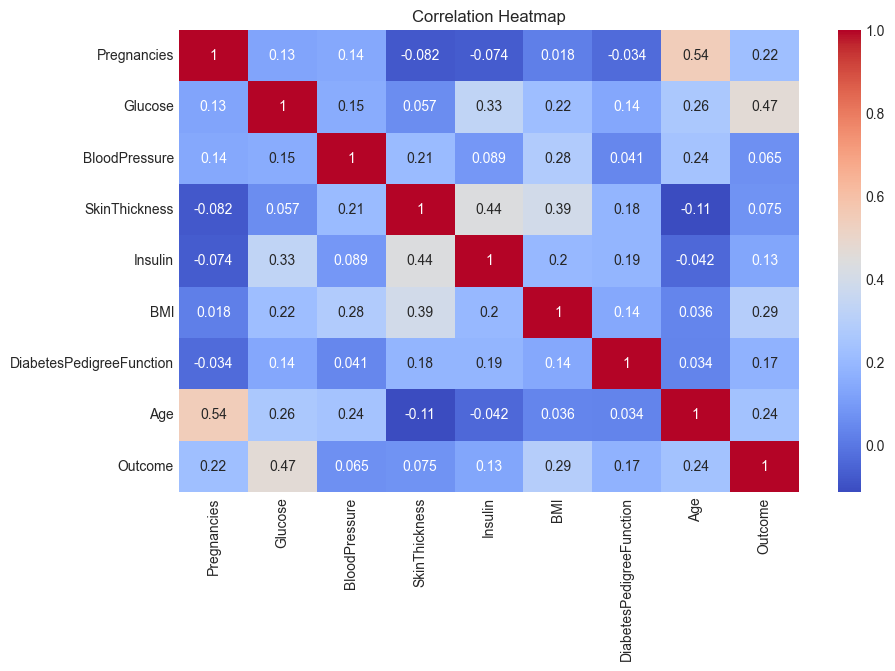

In [10]:
# correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

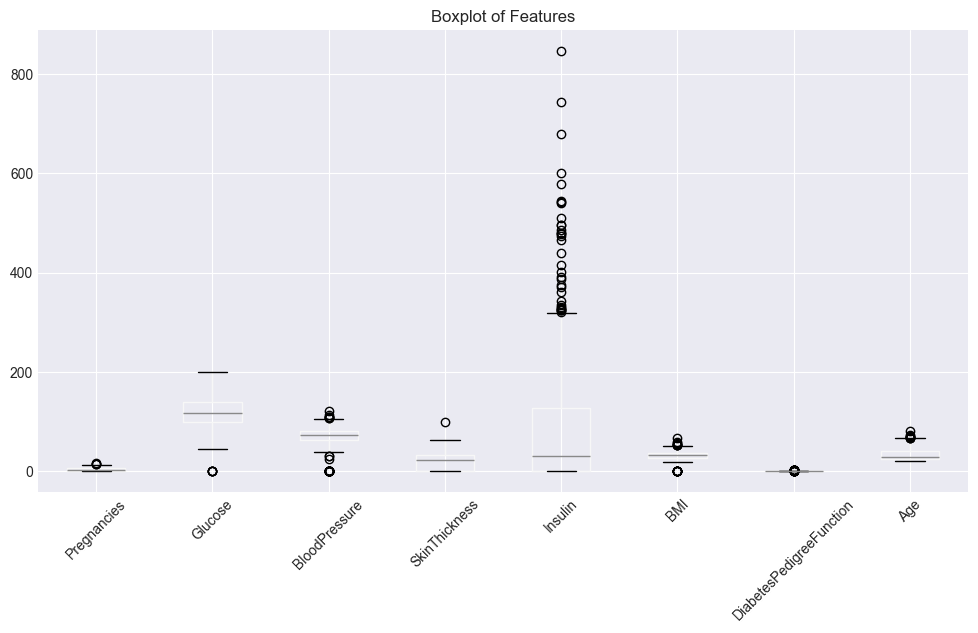

In [11]:
#boxplot of feature
df.drop('Outcome', axis=1).boxplot(figsize=(12,6), rot=45)
plt.title("Boxplot of Features")
plt.show()

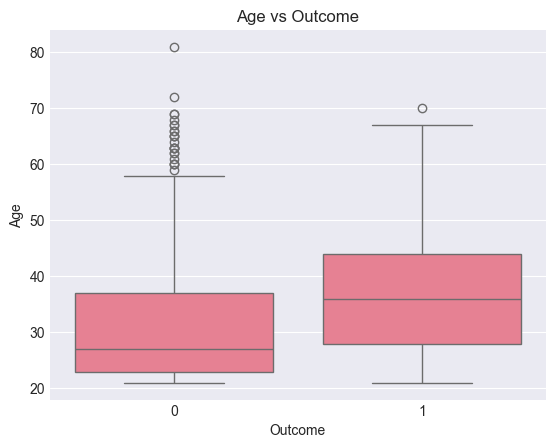

In [12]:
# Age Vs Outcomes
sns.boxplot(x='Outcome', y='Age', data=df)
plt.title("Age vs Outcome")
plt.show()

In [13]:
# Prepare data
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [14]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Support Vector Machine': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier()
}

In [17]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}")
    
    if name == 'Support Vector Machine':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_train = model.predict(X_train_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train)

    accuracy = accuracy_score(y_test, y_pred)
    train_accuracy = accuracy_score(y_train, y_pred_train)

    results[name] = accuracy

    print("Train Accuracy:", train_accuracy)
    print("Test Accuracy:", accuracy)
    print(confusion_matrix(y_test, y_pred))


Training Logistic Regression
Train Accuracy: 0.7931596091205212
Test Accuracy: 0.7142857142857143
[[82 18]
 [26 28]]

Training Support Vector Machine
Train Accuracy: 0.8355048859934854
Test Accuracy: 0.7532467532467533
[[83 17]
 [21 33]]

Training Decision Tree
Train Accuracy: 1.0
Test Accuracy: 0.7337662337662337
[[85 15]
 [26 28]]

Training Random Forest
Train Accuracy: 1.0
Test Accuracy: 0.7467532467532467
[[81 19]
 [20 34]]

Training KNN
Train Accuracy: 0.8045602605863192
Test Accuracy: 0.6688311688311688
[[77 23]
 [28 26]]


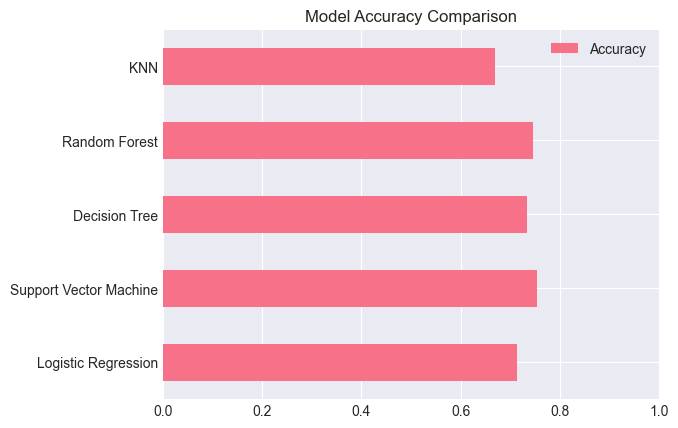

In [19]:
# Model comparison
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])

results_df.plot(kind='barh')
plt.title("Model Accuracy Comparison")
plt.xlim(0,1)
plt.show()

In [20]:
# Cross Validation
for name, model in models.items():
    if name == 'Support Vector Machine':
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5)
    
    print(name, "CV Mean:", scores.mean())

Logistic Regression CV Mean: 0.7785419165667067
Support Vector Machine CV Mean: 0.7540717046514728
Decision Tree CV Mean: 0.6890043982407037
Random Forest CV Mean: 0.7703851792616287
KNN CV Mean: 0.7411035585765694


In [21]:
# Hyper parameter tunning (Random forest)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}
Best Score: 0.7736505397840864


                    Feature  Importance
1                   Glucose    0.253534
5                       BMI    0.165477
7                       Age    0.137479
6  DiabetesPedigreeFunction    0.125035
2             BloodPressure    0.088952
0               Pregnancies    0.082452
4                   Insulin    0.077531
3             SkinThickness    0.069540


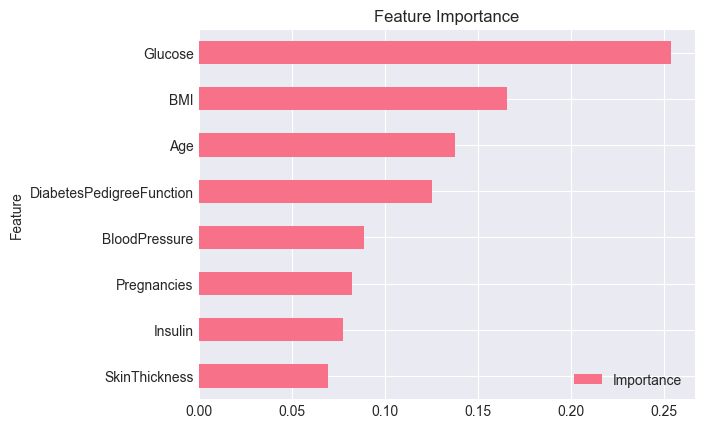

In [22]:
# Feature Importance (Random Forest)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

importance.plot(kind='barh', x='Feature', y='Importance')
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

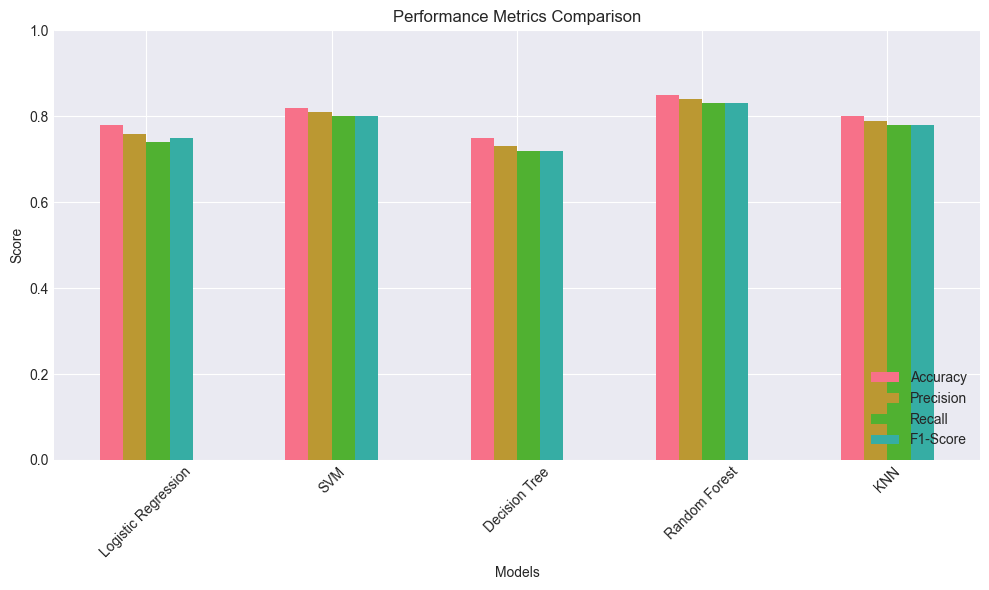

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: replace these values with your actual results
data = {
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest', 'KNN'],
    'Accuracy': [0.78, 0.82, 0.75, 0.85, 0.80],
    'Precision': [0.76, 0.81, 0.73, 0.84, 0.79],
    'Recall': [0.74, 0.80, 0.72, 0.83, 0.78],
    'F1-Score': [0.75, 0.80, 0.72, 0.83, 0.78]
}

df_metrics = pd.DataFrame(data)

# Set Model as index
df_metrics.set_index('Model', inplace=True)

# Plot grouped bar chart
df_metrics.plot(kind='bar', figsize=(10,6))

plt.title("Performance Metrics Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

In [23]:
# Finnal summary
best_model = results_df['Accuracy'].idxmax()
print("Best Model:", best_model)
print("Best Accuracy:", results_df.loc[best_model])

Best Model: Support Vector Machine
Best Accuracy: Accuracy    0.753247
Name: Support Vector Machine, dtype: float64
